<a href="https://colab.research.google.com/github/GigaGoriashvili/image-captioning/blob/main/data_and_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 1: Data Preprocessing and Model Training


## Setup and Imports
In this section, we mount Google Drive to access the dataset and import necessary Deep Learning libraries (TensorFlow/Keras).

In [ ]:
import os
import pickle
import numpy as np
from tqdm.notebook import tqdm # For progress bars

from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.utils import to_categorical, plot_model
from tensorflow.keras.layers import Input, Dense, LSTM, Embedding, Dropout, add

# Mounts Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Configuration and Paths

In [ ]:
BASE_DIR = '/content/drive/MyDrive/DL_Project'
IMAGES_DIR = os.path.join(BASE_DIR, 'images')
CAPTIONS_FILE = os.path.join(BASE_DIR, 'captions.txt')

# Working directory to save models/artifacts if it doesn't exist
WORKING_DIR = os.path.join(BASE_DIR, 'working')
if not os.path.exists(WORKING_DIR):
    os.makedirs(WORKING_DIR)

print(f"Images Directory: {IMAGES_DIR}")
print(f"Captions File: {CAPTIONS_FILE}")
print(f"Artifacts will be saved to: {WORKING_DIR}")

Images Directory: /content/drive/MyDrive/DL_Project/images
Captions File: /content/drive/MyDrive/DL_Project/captions.txt
Artifacts will be saved to: /content/drive/MyDrive/DL_Project/working


## Text Preprocessing
We need to load the captions, clean them (remove punctuation/numbers), and wrap them in startseq and endseq tokens so the model understands the start and end of a sentence.

In [ ]:
def load_captions(filename):
    with open(filename, 'r') as file:
        text = file.read()
    return text

def mapping_captions(text):
    mapping = {}
    for line in text.split('\n'):
        tokens = line.split(',')
        if len(tokens) < 2:
            continue
        image_id, caption = tokens[0], tokens[1:] # Handles cases where caption has commas
        image_id = image_id.split('.')[0] # Removes .jpg extension
        caption = " ".join(caption)

        if image_id not in mapping:
            mapping[image_id] = []
        mapping[image_id].append(caption)
    return mapping

def clean_captions(mapping):
    for key, captions in mapping.items():
        for i in range(len(captions)):
            caption = captions[i]
            # Preprocessing steps
            caption = caption.lower()
            caption = caption.replace('[^A-Za-z]', '') # Removing special chars
            caption = caption.replace('\s+', ' ')      # Removing extra spaces
            # Adds start and end tags
            caption = 'startseq ' + " ".join([word for word in caption.split() if len(word)>1 and word.isalpha()]) + ' endseq'
            captions[i] = caption

# Executes Loading and Cleaning
raw_text = load_captions(CAPTIONS_FILE)
captions_mapping = mapping_captions(raw_text)
clean_captions(captions_mapping)

print(f"Loaded {len(captions_mapping)} images.")
print(f"Example Caption: {list(captions_mapping.values())[0][0]}")

Loaded 8092 images.
Example Caption: startseq caption endseq


<>:28: SyntaxWarning: invalid escape sequence '\s'
<>:28: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-3214369330.py:28: SyntaxWarning: invalid escape sequence '\s'
  caption = caption.replace('\s+', ' ')      # Removing extra spaces


## Tokenization
We turn words into integers. We also need to determine the vocabulary size and the maximum length of a caption for padding purposes.

In [ ]:
# Collects all captions into a single list
all_captions = []
for key in captions_mapping:
    for caption in captions_mapping[key]:
        all_captions.append(caption)

# Tokenizing
tokenizer = Tokenizer()
tokenizer.fit_on_texts(all_captions)
vocab_size = len(tokenizer.word_index) + 1 # +1 for reserved 0 index
max_length = max(len(caption.split()) for caption in all_captions)

print(f"Vocabulary Size: {vocab_size}")
print(f"Max Description Length: {max_length}")

with open(os.path.join(WORKING_DIR, 'tokenizer.pkl'), 'wb') as f:
    pickle.dump(tokenizer, f)
print("Tokenizer saved to Google Drive.")

Vocabulary Size: 8353
Max Description Length: 32
Tokenizer saved to Google Drive.


## Image Feature Extraction (The Encoder)
We use a pre-trained VGG16 model. We remove the last classification layer and output the visual features (vector of size 4096).

In [ ]:
features_path = os.path.join(WORKING_DIR, 'features.pkl')

if os.path.exists(features_path):
    print("Loading existing features from Drive...")
    with open(features_path, 'rb') as f:
        features = pickle.load(f)
else:
    print("Features not found. Extracting from images (this takes time)...")
    model = VGG16()
    # Restructuring model to remove the last classification layer
    model = Model(inputs=model.inputs, outputs=model.layers[-2].output)

    features = {}
    directory = IMAGES_DIR

    for img_name in tqdm(os.listdir(directory)):
        img_path = directory + '/' + img_name
        image = load_img(img_path, target_size=(224, 224))
        image = img_to_array(image)
        image = image.reshape((1, image.shape[0], image.shape[1], image.shape[2]))
        image = preprocess_input(image)

        # Extracting features
        feature = model.predict(image, verbose=0)

        # Stores using image ID
        image_id = img_name.split('.')[0]
        features[image_id] = feature

    with open(features_path, 'wb') as f:
        pickle.dump(features, f)
    print("Features saved to Google Drive.")

print(f"Extracted features for {len(features)} images.")

Features not found. Extracting from images (this takes time)...


  0%|          | 0/8091 [00:00<?, ?it/s]

Features saved to Google Drive.
Extracted features for 8091 images.


## Data Generator
We cannot load all training data (images + text sequences) into RAM at once. We use a Python Generator to feed data to the model batch-by-batch.

In [ ]:
def data_generator(data_keys, mapping, features, tokenizer, max_length, vocab_size, batch_size):
    # Loop indefinitely
    X1, X2, y = list(), list(), list()
    n = 0
    while 1:
        for key in data_keys:
            n += 1
            captions = mapping[key]
            # Retrieves image feature
            if key not in features:
                continue
            feature = features[key][0] # Unpack the array

            for caption in captions:
                seq = tokenizer.texts_to_sequences([caption])[0]
                # Splits one sequence into multiple X,y pairs
                for i in range(1, len(seq)):
                    in_seq, out_seq = seq[:i], seq[i]
                    in_seq = pad_sequences([in_seq], maxlen=max_length)[0]
                    out_seq = to_categorical([out_seq], num_classes=vocab_size)[0]

                    X1.append(feature)
                    X2.append(in_seq)
                    y.append(out_seq)

            # Yield the batch data
            if n == batch_size:
                yield [np.array(X1), np.array(X2)], np.array(y)
                X1, X2, y = list(), list(), list()
                n = 0

##  Model Definition
We define the architecture:
* **Image Model**: Processes the 4096-sized feature vector.
* **Language Model**: Processes the text input (Embeddings + LSTM).
* **Decoder**: Combines both and predicts the next word.

In [ ]:
# Feature Extractor Model (Image)
inputs1 = Input(shape=(4096,))
fe1 = Dropout(0.5)(inputs1)
fe2 = Dense(256, activation='relu')(fe1)

# Sequence Model (Text)
inputs2 = Input(shape=(max_length,))
se1 = Embedding(vocab_size, 256, mask_zero=True)(inputs2)
se2 = Dropout(0.5)(se1)
se3 = LSTM(256)(se2)

# Decoder Model (Combine)
decoder1 = add([fe2, se3])
decoder2 = Dense(256, activation='relu')(decoder1)
outputs = Dense(vocab_size, activation='softmax')(decoder2)

model = Model(inputs=[inputs1, inputs2], outputs=outputs)
model.compile(loss='categorical_crossentropy', optimizer='adam')

# Visualization
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 32)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_2       │ (None, 4096)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 32, 256)   │  2,138,368 │ input_layer_3[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 4096)      │          0 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 32, 256)   │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 32)        │          0 │ input_layer_3[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │  1,048,832 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 256)       │    525,312 │ dropout_1[0][0],  │
│                     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 256)       │          0 │ dense[0][0],      │
│                     │                   │            │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │     65,792 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 8353)      │  2,146,721 │ dense_1[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,925,025 (22.60 MB)

 Trainable params: 5,925,025 (22.60 MB)

 Non-trainable params: 0 (0.00 B)

## Training
We split the image IDs into training and validation sets, then train the model.

In [ ]:
# Train/Test Split (Keys only)
image_ids = list(captions_mapping.keys())
split = int(len(image_ids) * 0.90)
train = image_ids[:split]
test = image_ids[split:]

# Parameters
epochs = 20
batch_size = 32
steps = len(train) // batch_size

def data_generator(data_keys, mapping, features, tokenizer, max_length, vocab_size, batch_size):
    # Loop indefinitely
    X1, X2, y = list(), list(), list()
    n = 0
    while 1:
        for key in data_keys:
            n += 1
            captions = mapping[key]
            # Retrieves image feature
            if key not in features:
                continue
            feature = features[key][0]

            for caption in captions:
                seq = tokenizer.texts_to_sequences([caption])[0]
                # Splits one sequence into multiple X,y pairs
                for i in range(1, len(seq)):
                    in_seq, out_seq = seq[:i], seq[i]
                    in_seq = pad_sequences([in_seq], maxlen=max_length, padding='post')[0]
                    out_seq = to_categorical([out_seq], num_classes=vocab_size)[0]

                    X1.append(feature)
                    X2.append(in_seq)
                    y.append(out_seq)

            # Yield the batch data
            if n == batch_size:
                yield (np.array(X1), np.array(X2)), np.array(y)
                X1, X2, y = list(), list(), list()
                n = 0

# Generator
generator = data_generator(train, captions_mapping, features, tokenizer, max_length, vocab_size, batch_size)

# Training
history = model.fit(generator, epochs=epochs, steps_per_epoch=steps, verbose=1)

Epoch 1/20
227/227 ━━━━━━━━━━━━━━━━━━━━ 53s 229ms/step - loss: 5.7957
Epoch 2/20
227/227 ━━━━━━━━━━━━━━━━━━━━ 51s 225ms/step - loss: 4.0800
Epoch 3/20
227/227 ━━━━━━━━━━━━━━━━━━━━ 51s 224ms/step - loss: 3.6118
Epoch 4/20
227/227 ━━━━━━━━━━━━━━━━━━━━ 50s 222ms/step - loss: 3.3331
Epoch 5/20
227/227 ━━━━━━━━━━━━━━━━━━━━ 51s 223ms/step - loss: 3.1323
Epoch 6/20
227/227 ━━━━━━━━━━━━━━━━━━━━ 51s 224ms/step - loss: 2.9792
Epoch 7/20
227/227 ━━━━━━━━━━━━━━━━━━━━ 51s 224ms/step - loss: 2.8609
Epoch 8/20
227/227 ━━━━━━━━━━━━━━━━━━━━ 51s 225ms/step - loss: 2.7683
Epoch 9/20
227/227 ━━━━━━━━━━━━━━━━━━━━ 51s 226ms/step - loss: 2.6924
Epoch 10/20
227/227 ━━━━━━━━━━━━━━━━━━━━ 51s 224ms/step - loss: 2.6211
Epoch 11/20
227/227 ━━━━━━━━━━━━━━━━━━━━ 51s 223ms/step - loss: 2.5572
Epoch 12/20
227/227 ━━━━━━━━━━━━━━━━━━━━ 51s 226ms/step - loss: 2.5040
Epoch 13/20
227/227 ━━━━━━━━━━━━━━━━━━━━ 51s 225ms/step - loss: 2.4535
Epoch 14/20
227/227 ━━━━━━━━━━━━━━━━━━━━ 51s 225ms/step - loss: 2.4129
Epoch 15/20
227

## Saving and Analysis

Model saved to Google Drive.


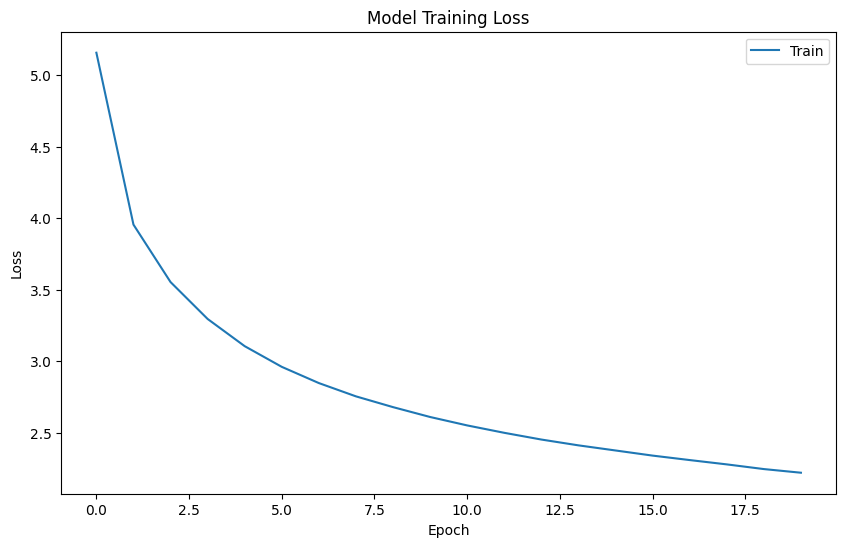

In [ ]:
# Saving the final model
model.save(os.path.join(WORKING_DIR, 'final_caption_model.h5'))
print("Model saved to Google Drive.")

# Plots Loss
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'])
plt.title('Model Training Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train'], loc='upper right')
plt.show()

## Verification of Artifacts

In [ ]:
import os

files_needed = ['final_caption_model.h5', 'tokenizer.pkl', 'features.pkl']
print(f"Checking {WORKING_DIR}...")

for f in files_needed:
    path = os.path.join(WORKING_DIR, f)
    if os.path.exists(path):
        print(f"[OK] {f} exists. Size: {os.path.getsize(path)/1024/1024:.2f} MB")
    else:
        print(f"[FAIL] {f} is MISSING. Please re-run the relevant sections.")

Checking /content/drive/MyDrive/DL_Project/working...
[OK] final_caption_model.h5 exists. Size: 67.85 MB
[OK] tokenizer.pkl exists. Size: 0.31 MB
[OK] features.pkl exists. Size: 126.90 MB
